<a href="https://colab.research.google.com/github/hoangchaulanbao/HocmayNC/blob/main/btcn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yêu cầu:  # A. Mô hình Hồi quy (Regression Model)
-  Thuật toán: Triển khai Linear Regression sử dụng Gradient Descent.
- Đánh giá: Sử dụng các chỉ số MAE, MSE, RMSE và R2 Score. Giải thích ý nghĩa của R2 âm (nếu có) so với baseline.



# Bài toán: Dự đoán giá xe ô tô cũ dựa trên các đặc điểm: manufacturer, mode, engine size, fuel type , mileage, và year of manufacture.

# Vấn đề:
- Dự đoán giá của một chiếc xe đã qua sử dụng không phải là việc đơn giản — nó phụ thuộc vào uy tín thương hiệu, tuổi thọ xe, mức tiêu thụ nhiên liệu, số km đã đi và nhiều yếu tố khác.
- xây dựng một mô hình hồi quy giúp ánh xạ các đặc điểm đó thành mức giá thị trường hợp lý, hỗ trợ người mua và người bán đưa ra những quyết định dựa trên dữ liệu."
# Quy trình bao gồm:
- Bước 1: Đọc dữ liệu
- Bước 2: EDA
- Bước 3: CHIA TẬP DỮ LIỆU
- Bước 4: Feature engineering
- Bước 5: Xây dựng Linear Regression bằng Gradient Descent
- BƯỚC 6: Đánh giá hiệu suất: (MAE, MSE, RMSE, R2)
- Bước 7: Phân tích kết quả (Overfitting / Underfitting)


# import thư viện

In [295]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── Matplotlib dark theme ───────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0a0e1a",
    "axes.facecolor":    "#111827",
    "axes.edgecolor":    "#1e3a5f",
    "axes.labelcolor":   "#94a3b8",
    "xtick.color":       "#64748b",
    "ytick.color":       "#64748b",
    "text.color":        "#e2e8f0",
    "grid.color":        "#1e293b",
    "grid.linewidth":    0.6,
    "font.family":       "DejaVu Sans",
    "axes.titlesize":    14,
    "axes.labelsize":    12,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

PALETTE   = ["#00d4ff","#00f5c8","#ff6b9d","#ffb347","#c084fc","#34d399","#f87171"]
BLUE_CYAN = ["#00d4ff","#00f5c8"]
print("Thư viện đã được import .")


Thư viện đã được import .


# **# Bước 1- Đọc dữ liệu- (LOAD DATA)**

In [286]:
url = "https://raw.githubusercontent.com/hoangchaulanbao/HocmayNC/main/car_sales_data.csv"
df = pd.read_csv(url)


rows, cols = df.shape
print("Số dòng:", rows)
print("Số cột:", cols)
# xuất 5 dòng đầu
df.head()

Số dòng: 50000
Số cột: 7


,Manufacturer,Model,Engine size,Fuel type,Year of manufacture,Mileage,Price
0,Ford,Fiesta,1.0,Petrol,2002,127300,3074
1,Porsche,718 Cayman,4.0,Petrol,2016,57850,49704
2,Ford,Mondeo,1.6,Diesel,2014,39190,24072
3,Toyota,RAV4,1.8,Hybrid,1988,210814,1705
4,VW,Polo,1.0,Petrol,2006,127869,4101


# **# BƯỚC 2: KHÁM PHÁ DỮ LIỆU (EDA)**

# **#2.1 Thống kê mô tả (Descriptive Statistics)**
- Check Cấu trúc
- Số liệu đặc trưng
- Kiểm tra sức khoe dữ liệu: isnull, duplicate

# **- Check cấu trúc:**

In [238]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Manufacturer         50000 non-null  object 
 1   Model                50000 non-null  object 
 2   Engine size          50000 non-null  float64
 3   Fuel type            50000 non-null  object 
 4   Year of manufacture  50000 non-null  int64  
 5   Mileage              50000 non-null  int64  
 6   Price                50000 non-null  int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 2.7+ MB


# **- Số liệu đặc trưng**

In [239]:
df.describe()

,Engine size,Year of manufacture,Mileage,Price
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.773058,2004.209440,112497.320700,13828.903160
std,0.734108,9.645965,71632.515602,16416.681336
min,1.000000,1984.000000,630.000000,76.000000
25%,1.400000,1996.000000,54352.250000,3060.750000
50%,1.600000,2004.000000,100987.500000,7971.500000
75%,2.000000,2012.000000,158601.000000,19026.500000
max,5.000000,2022.000000,453537.000000,168081.000000


#**- Kiểm tra sức khỏe dữ liệu (isnull,duplicate))**

# - Kiểm tra isnull

In [240]:
null_counts = df.isnull().sum()
print(null_counts)
print(f"\n số lượng giá trị thiếu: {null_counts.sum()}")

Manufacturer           0
Model                  0
Engine size            0
Fuel type              0
Year of manufacture    0
Mileage                0
Price                  0
dtype: int64

 số lượng giá trị thiếu: 0


# - Kiểm tra trùng và xóa trùng

In [287]:
print(f"Số dòng bị trùng: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Sau khi xòa dòng trùng   → Số dòng còn lại: {df.shape[0]}")

Số dòng bị trùng: 12
Sau khi xòa dòng trùng   → Số dòng còn lại: 49988


# **- Kiểm tra invalid data (có cột nào chứa giá trị <0)**

In [242]:
print("Kiểm tra giá trị âm trong DataFrame:")
for col in df.select_dtypes(include=np.number).columns:
    if (df[col] < 0).any():
        print(f"Cột '{col}' có chứa giá trị âm.")
    else:
        print(f"Cột '{col}' không chứa giá trị âm.")

Kiểm tra giá trị âm trong DataFrame:
Cột 'Engine size' không chứa giá trị âm.
Cột 'Year of manufacture' không chứa giá trị âm.
Cột 'Mileage' không chứa giá trị âm.
Cột 'Price' không chứa giá trị âm.


# **- Kiểm tra phạm vi dữ liệu (Sanity Check)**

In [243]:
# Kiểm tra Engine size
print("Kiểm tra Engine size:")
# Giá trị 0 hoặc quá lớn bất thường (ví dụ: > 6.0)
zero_engine_size = df[df['Engine size'] == 0].shape[0]
large_engine_size = df[df['Engine size'] > 6.0].shape[0]

if zero_engine_size > 0:
    print(f"Có {zero_engine_size} xe có Engine size = 0.")
if large_engine_size > 0:
    print(f"Có {large_engine_size} xe có Engine size lớn hơn 6.0L (bất thường).")
if zero_engine_size == 0 and large_engine_size == 0:
    print("Engine size không có giá trị 0 hoặc quá lớn bất thường (> 6.0L).")

# Kiểm tra Year of manufacture
print("\nKiểm tra Year of manufacture:")
current_year = 2026 # Lấy năm hiện tại
# Năm quá khứ xa xôi (ví dụ: trước 1980) hoặc năm tương lai
old_year = df[df['Year of manufacture'] < 2026].shape[0]
future_year = df[df['Year of manufacture'] > current_year].shape[0]

if old_year > 0:
    print(f"Có {old_year} xe có Year of manufacture trước năm 1980.")
if future_year > 0:
    print(f"Có {future_year} xe có Year of manufacture sau năm hiện tại ({current_year}).")
if old_year == 0 and future_year == 0:
    print("Year of manufacture nằm trong phạm vi hợp lý (sau 1980 và không vượt quá năm hiện tại).")

Kiểm tra Engine size:
Engine size không có giá trị 0 hoặc quá lớn bất thường (> 6.0L).

Kiểm tra Year of manufacture:
Có 49988 xe có Year of manufacture trước năm 1980.


# NHẬN XÉT TỔNG QUAN DỮ LIỆU NHƯ SAU
- Không có giá trị null -dataset sạch  
- Có 12 dòng trùng - bị xóa khỏi từ 50,000 dòng
- Price khoảng £76 -£168,081
- Engine size: 1.0 L -> 5.0 L
- Mileage trung bình ~ 112,515 km
- =Year of manuafacture : 1984 -2022
- Fuel types: Petrol, Diesel, Hybrid


# **# 2.2 Phân tích đơn biến (Univariate Analysis)**
Xem xét từng cột một cách độc lập để hiểu sự phân phối:
- Biến số numerical
- Biến phân loại Categorical

# **- Kiểm tra số lượng giá trị của mỗi cột**

In [244]:
df.nunique()

,0
Manufacturer,5
Model,15
Engine size,14
Fuel type,3
Year of manufacture,39
Mileage,44971
Price,25045


# **- Kiểm tra kiểu dữ liệu của từng cột**

In [245]:
df.dtypes

,0
Manufacturer,object
Model,object
Engine size,float64
Fuel type,object
Year of manufacture,int64
Mileage,int64
Price,int64


# **-Biểu đồ phân phối của cột  Price**

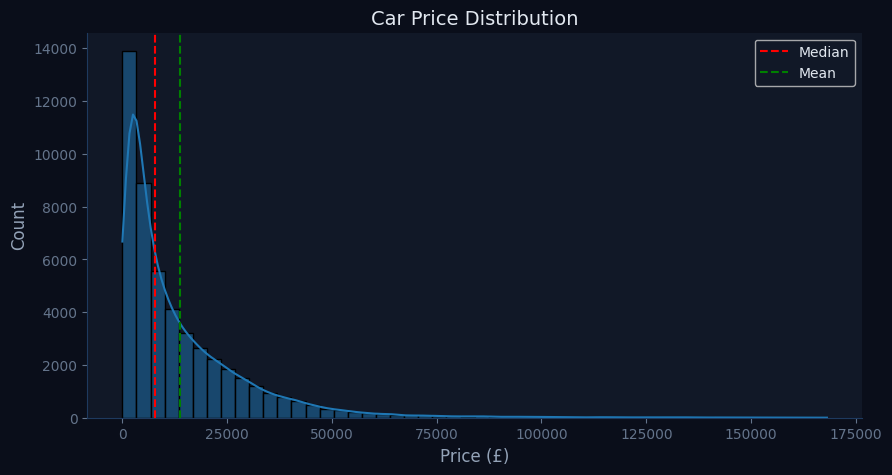

In [246]:


# 1. Khởi tạo khung hình
plt.figure(figsize=(10, 5))

# 2. Vẽ biểu đồ phân phối
sns.histplot(df['Price'], bins=50, kde=True)

# 3. Thêm đường Median (Trung vị) và Mean (Trung bình)
plt.axvline(df['Price'].median(), color='red', linestyle='--', label='Median')
plt.axvline(df['Price'].mean(), color='green', linestyle='--', label='Mean')

# 4. Thêm tiêu đề và chú thích
plt.title('Car Price Distribution')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.legend()

plt.show()

- Biến mục tiêu Price có hiện tượng lệch phải nghiêm trọng với sự xuất hiện của nhiều giá trị ngoại lai ở phân khúc giá cao (> 75.000 £).
- Đường Mean cao hơn hẳn Median cho thấy dữ liệu bị chi phối bởi các dòng xe hạng sang.

==>**Cần  áp dụng Log Transformation cho biến mục tiêu**

# **- Biểu đồ phân phối của cột Engine Size**

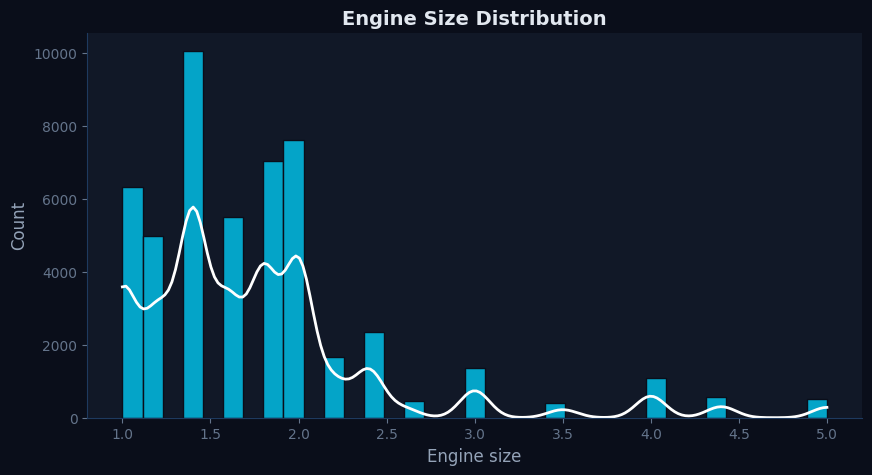

In [247]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Engine size'], bins=35, kde=True, color='#00d4ff', edgecolor='#0a0e1a', alpha=0.75)
plt.gca().lines[0].set(color='#ffffff', linewidth=2) # Làm đường KDE màu trắng
plt.title('Engine Size Distribution', fontsize=14, fontweight='bold')
plt.show()



-  Biểu đồ cho thấy dữ liệu bị lệch phải rõ rệt. Đa số các xe trong tập dữ liệu tập trung ở phân khúc động cơ nhỏ (từ 1.0 đến 2.0).
- Giá trị phổ biến: xuất hiện mạnh nhất quanh mốc 1.4, 1.6, và 2.0. Đây là các kích thước động cơ tiêu chuẩn của dòng xe phổ thông.
-  Từ mốc 2.5 trở lên, số lượng xe giảm dần nhưng kéo dài đến tận 5.0. Đây là những dòng xe hạng sang hoặc xe thể thao công suất lớn.
- Phát hiện giá trị ngoại lai (Outliers)
Các cột đơn lẻ ở vùng 4.0 đến 5.0 có số lượng rất ít so với phần còn lại.


**Cần :Biến đổi dữ liệu hoặc xử lý outliers**

# **- Biểu đồ Phân của cột "Year of Manufacture"**

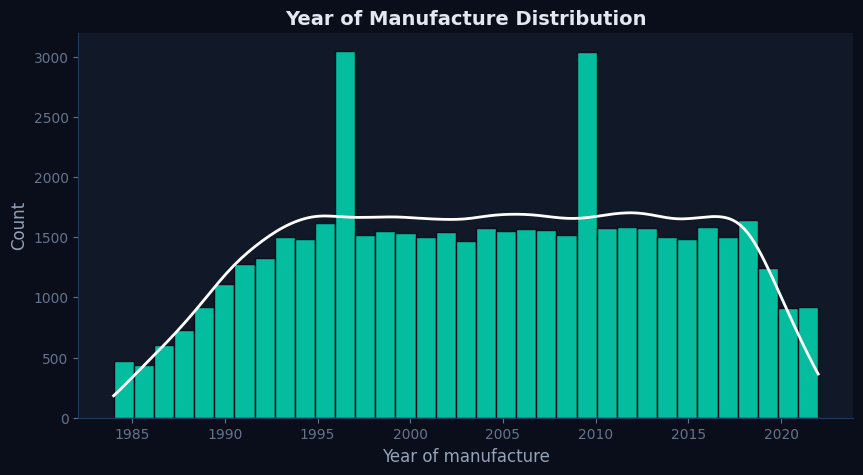

In [248]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Year of manufacture'], bins=35, kde=True, color='#00f5c8', edgecolor='#0a0e1a', alpha=0.75)
plt.gca().lines[0].set(color='#ffffff', linewidth=2)
plt.title('Year of Manufacture Distribution', fontsize=14, fontweight='bold')
plt.show()


- Phân phối năm sản xuất của các mẫu xe khá đồng đều trong giai đoạn 1995-2018, đảm bảo tính đại diện cho nhiều đời xe.
-  Tuy nhiên, sự xuất hiện của các điểm tăng vọt số lượng vào năm 1997 và 2010 cần được lưu ý vì có thể gây ảnh hưởng cục bộ đến dự báo.

**Cần chuyển đổi biến này sang CarAge** giúp mô hình nắm bắt tốt hơn quy luật giảm giá theo thời gian của phương tiện.

# **- Biểu đồ Phân phối của cột Mileage**


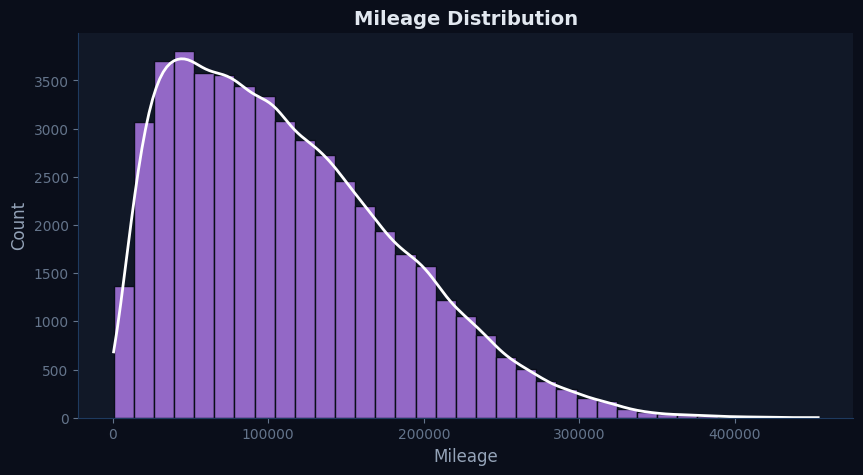

In [250]:
plt.figure(figsize=(10, 5))
sns.histplot(df['Mileage'], bins=35, kde=True, color='#c084fc', edgecolor='#0a0e1a', alpha=0.75)
plt.gca().lines[0].set(color='#ffffff', linewidth=2)
plt.title('Mileage Distribution', fontsize=14, fontweight='bold')
plt.show()


- Mileage có phân phối lệch phải nghiêm trọng với đuôi dài, mô hình Linear Regression sẽ dễ bị chi phối bởi các giá trị cực đại.

- Việc **áp dụng Log Transformation** là cần thiết để nén các giá trị lớn này lại,


# **- Biểu đồ phân phối của cột Manuafacturer**

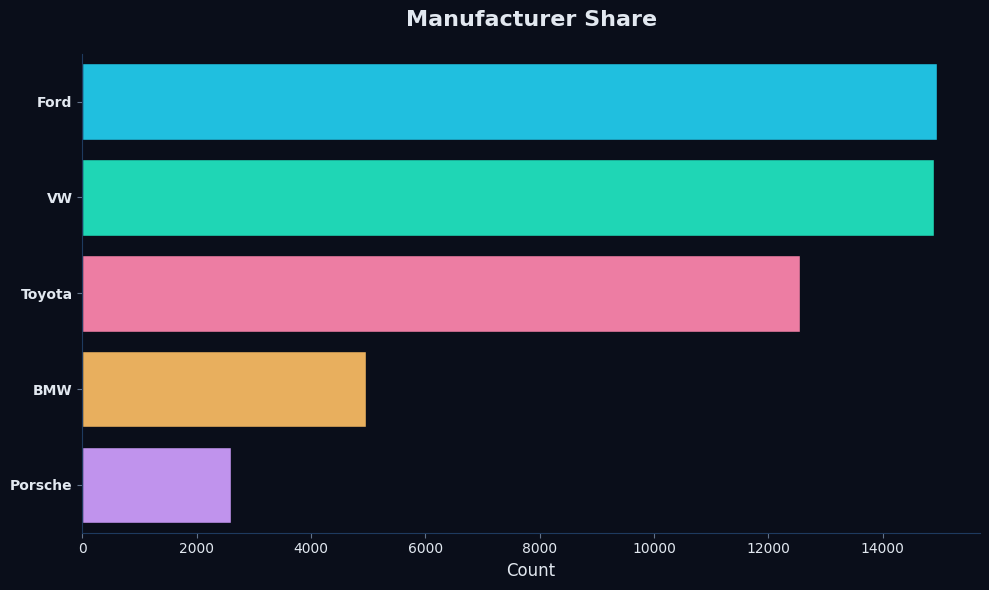

In [251]:


# 1. Chuẩn bị dữ liệu (lấy top các hãng để biểu đồ không bị quá dài)
vc = df['Manufacturer'].value_counts()
colors = ['#00d4ff', '#00f5c8', '#ff6b9d', '#ffb347', '#c084fc']

# 2. Vẽ biểu đồ thanh ngang
plt.figure(figsize=(10, 6), facecolor='#0a0e1a')
ax = sns.barplot(x=vc.values, y=vc.index, palette=colors, edgecolor='#0a0e1a')

# 3. Tùy chỉnh giao diện "Dark Mode"
ax.set_facecolor('#0a0e1a')
plt.title('Manufacturer Share', color='#e2e8f0', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Count', color='#e2e8f0', fontsize=12)
plt.ylabel('', color='#e2e8f0') # Bỏ chữ 'Manufacturer' bên cạnh cho gọn

# Chỉnh màu chữ cho các hãng và các con số trên trục
plt.xticks(color='#e2e8f0')
plt.yticks(color='#e2e8f0', fontweight='bold')

plt.tight_layout()
plt.show()


- gồm 5 hãng xe với thị phần chênh lệch rõ rệt.
- Các hãng xe phổ thông như Ford và Toyota chiếm đa số,
- trong khi các hãng hạng sang như Porsche chiếm tỷ trọng thấp.

==>  **cần thực hiện mã hóa đặc trưng (Encoding)** để hiểu được giá trị thương hiệu cho biến Manufacturer."


# **- Biểu đồ cho cột Fuel type**

- Nhiên liệu nào chiếm ưu thế
- Nhiên liệu nào có giá bán cao nhất - quan hệ với price
- Loại nhiên liệu nào đi kèm với số dặm (Mileage) cao hơn hoặc dung tích động cơ (Engine size) lớn hơn? -quan hệ với hiệu suất


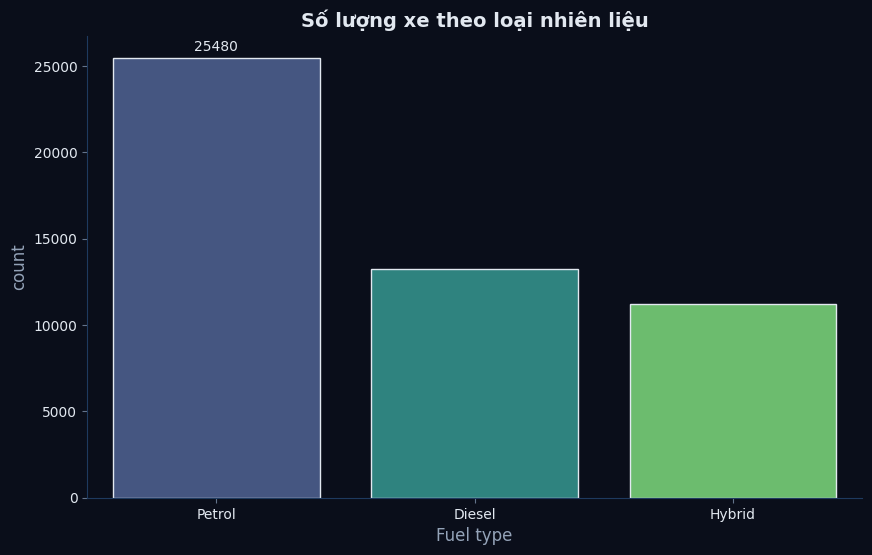

In [252]:


# Thiết lập màu sắc và style chung
plt.rcParams['axes.facecolor'] = '#0a0e1a'
plt.rcParams['figure.facecolor'] = '#0a0e1a'

# --- BIỂU ĐỒ 1: SỐ LƯỢNG XE THEO NHIÊN LIỆU ---
plt.figure(figsize=(10, 6))
ax1 = sns.countplot(data=df, x='Fuel type', palette='viridis', edgecolor='#e2e8f0')

# Gắn nhãn số lượng trên đầu mỗi cột
ax1.bar_label(ax1.containers[0], color='#e2e8f0', padding=3)

plt.title('Số lượng xe theo loại nhiên liệu', color='#e2e8f0', fontweight='bold')
plt.xticks(color='#e2e8f0')
plt.yticks(color='#e2e8f0')
plt.show()




- Tập dữ liệu có sự phân hóa rõ rệt về loại nhiên liệu với ưu thế thuộc về động cơ Petrol (chiếm hơn 50% tổng lượng mẫu).
- Tuy nhiên, các nhóm Diesel và Hybrid vẫn duy trì số lượng mẫu đủ lớn (trên 10.000 mẫu mỗi loại), đảm bảo tính khách quan và độ tin cậy khi mô hình thực hiện huấn luyện và dự báo trên các phân khúc động cơ khác nhau."

# **- Phân phối cột Model**

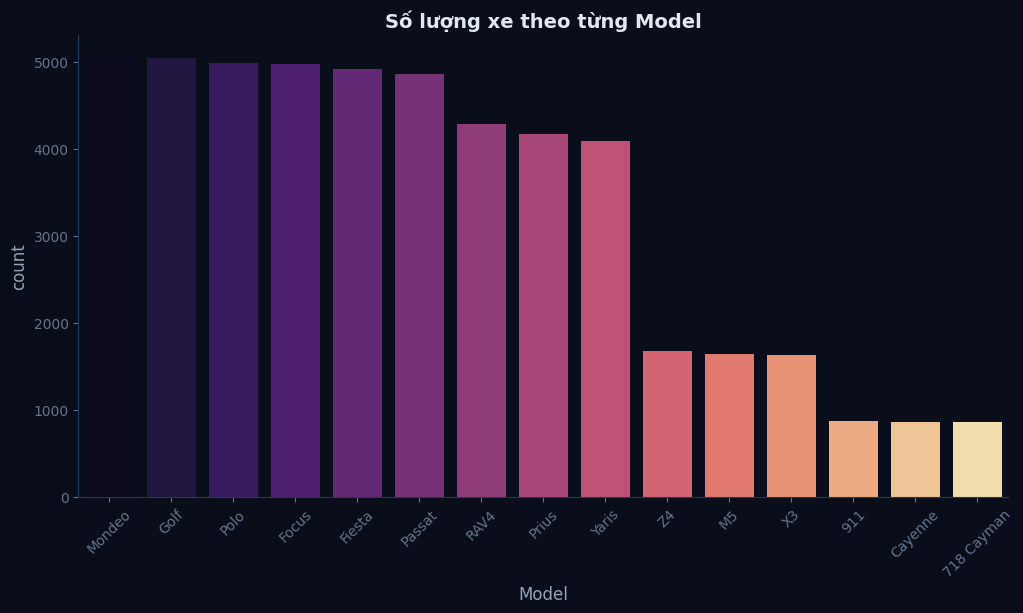

In [253]:


plt.figure(figsize=(12, 6))
# Sắp xếp theo số lượng từ cao xuống thấp
order = df['Model'].value_counts().index

sns.countplot(x='Model', data=df, order=order, palette='magma')

plt.title('Số lượng xe theo từng Model', fontsize=14, fontweight='bold')
plt.xticks(rotation=45) # Xoay chữ 45 độ để không bị đè nhau
plt.show()

- Nhóm chủ lực hơn > 4000 xe: Bao gồm các dòng xe phổ thông như Mondeo, Golf, Polo, Focus, Fiesta, Passat, RAV4, Prius, Yaris.
- Nhóm trung bình (Khoảng 1500 - 2000 xe): Bao gồm Z4, M5, X3. Đây thường là các dòng xe cận sang hoặc xe thể thao.
- Nhóm thiểu số (Dưới 1000 xe): Bao gồm Cayenne, 718 Cayman. Đây chính là những dòng siêu xe/xe sang của Porsche mà chúng ta thấy có giá cực cao ở các biểu đồ trước.

- Độ tin cậy cao: Với các dòng xe bên trái (như Mondeo hay Golf), mô hình sẽ dự báo giá rất chính xác vì có tới 5000 mẫu để học.
- Thách thức từ nhóm bên phải: Nhóm Cayenne tuy số lượng ít (dưới 1000 xe) nhưng lại là nhóm có biến động giá lớn nhất và giá cao nhất.


# **# 2.2 Phân tích đa biến ( Multivariate Analysis)**
- **Tìm mối quan hệ giữa các cột với biến mục tiêu**

# **- Price & Fuel Type**

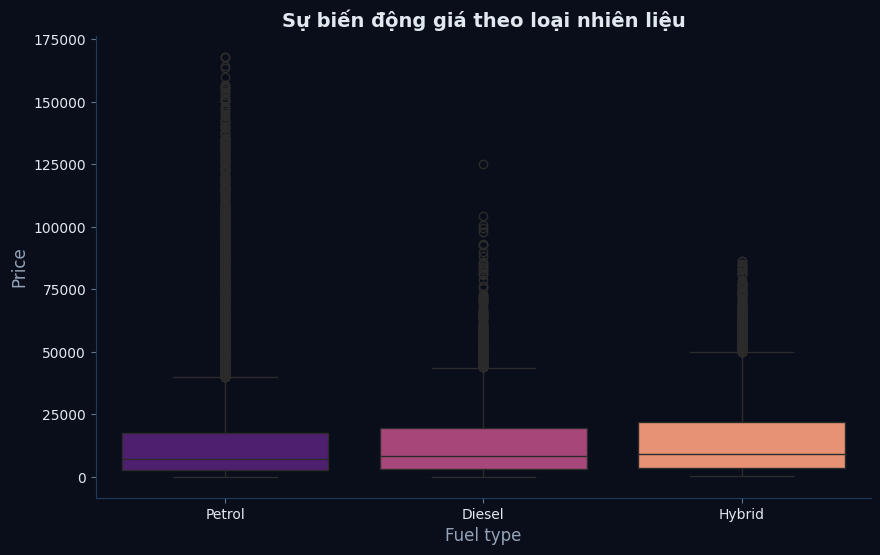

In [254]:
# --- BIỂU ĐỒ 2: SO SÁNH GIÁ THEO NHIÊN LIỆU ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Fuel type', y='Price', palette='magma')

plt.title('Sự biến động giá theo loại nhiên liệu', color='#e2e8f0', fontweight='bold')
plt.xticks(color='#e2e8f0')
plt.yticks(color='#e2e8f0')
plt.grid(axis='y', alpha=0.1) # Thêm lưới ngang mờ
plt.show()

- Biểu đồ Boxplot cho thấy loại nhiên liệu Hybrid có mức giá trung bình cao nhất, phản ánh giá trị công nghệ của dòng xe này.
- Tuy nhiên, nhóm xe Petrol lại sở hữu nhiều giá trị ngoại lai cực đại nhất, gây ra sự biến động lớn về giá.
- Sự khác biệt về phân phối giá giữa các loại nhiên liệu khẳng định đây là một đặc trưng quan trọng cần được mã hóa kỹ lưỡng để mô hình có thể dự báo chính xác hơn."


# **- Manufacturer và Fuel Type**

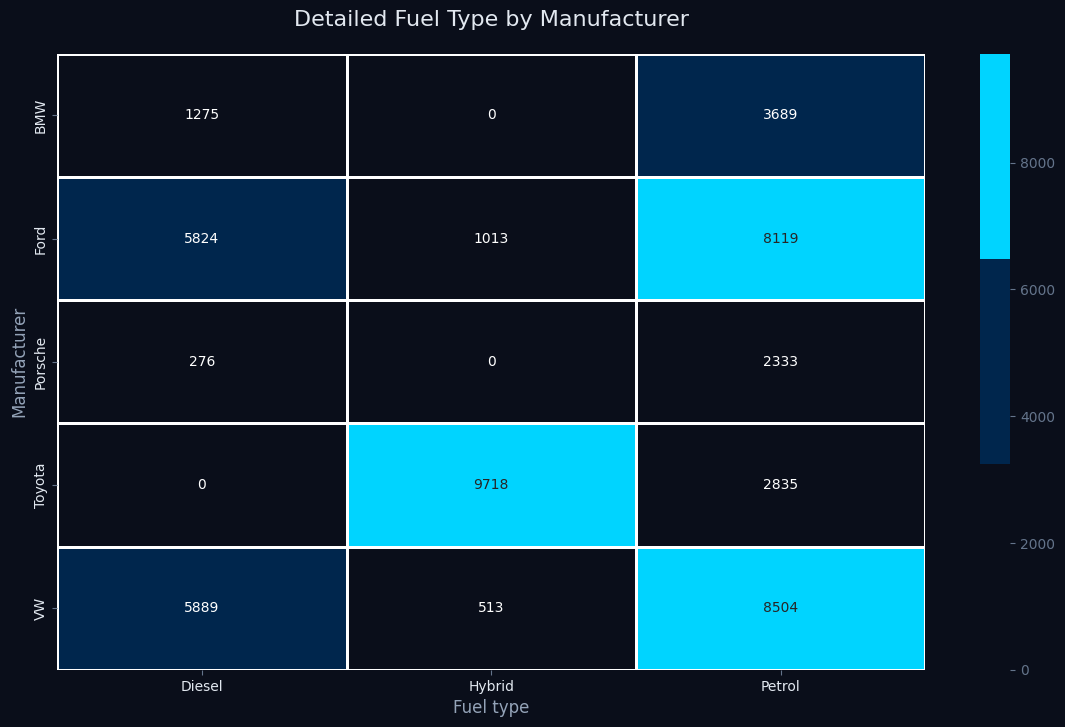

In [255]:
# Tách riêng Heatmap và xoay ngang để tên hãng không bị nghiêng
plt.figure(figsize=(14, 8), facecolor='#0a0e1a')
pivot = pd.crosstab(df['Manufacturer'], df['Fuel type']) # Đảo Manufacturer sang hàng ngang

sns.heatmap(pivot, annot=True, fmt='d', cmap=['#0a0e1a','#00264d','#00d4ff'],
            linewidths=1, cbar=True)

plt.title('Detailed Fuel Type by Manufacturer', color='#e2e8f0', fontsize=16, pad=20)
plt.xticks(color='#e2e8f0')
plt.yticks(color='#e2e8f0')
plt.show()


- Phân tích đa biến qua Heatmap cho thấy sự phân hóa rõ rệt về công nghệ động cơ giữa các nhà sản xuất.
- Toyota chiếm lĩnh phân khúc Hybrid,
-  trong khi các hãng xe Đức như BMW và Porsche tập trung chủ yếu vào động cơ xăng.
- Sự phân bố không đồng đều này là cơ sở quan trọng để mô hình Linear Regression phân loại và định giá chính xác hơn cho từng nhóm đối tượng khách hàng mục tiêu của mỗi hãng."

# **- Price & Mileage**





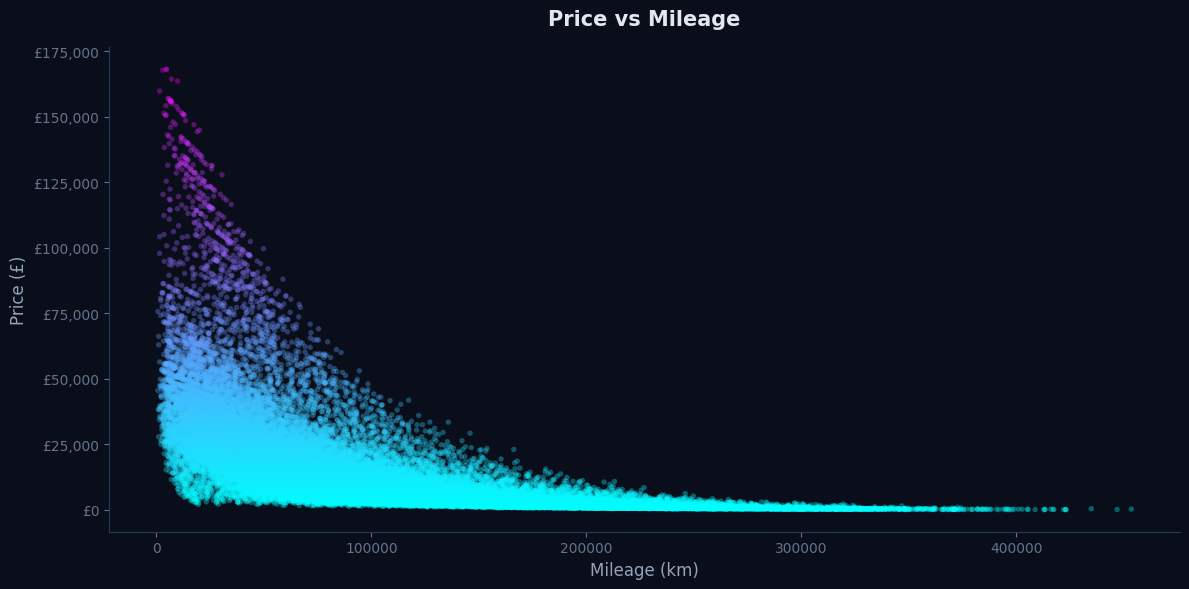

In [256]:


# 1. Khởi tạo và vẽ nhanh bằng Seaborn
plt.figure(figsize=(12, 6), facecolor='#0a0e1a')
ax = sns.scatterplot(data=df, x='Mileage', y='Price', hue='Price',
                     palette='cool', alpha=0.35, s=15, edgecolor='none', legend=False)

# 2. Định dạng trục và màu sắc giao diện tối
ax.set_facecolor('#0a0e1a')
ax.set_title('Price vs Mileage', fontsize=15, fontweight='bold', color='#e2e8f0', pad=16)
ax.set_xlabel('Mileage (km)', color='#94a3b8')
ax.set_ylabel('Price (£)', color='#94a3b8')

# 3. Định dạng số tiền có dấu phẩy và ký hiệu £
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{int(x):,}'))
ax.tick_params(colors='#64748b')

plt.tight_layout()
plt.show()


 Mileage càng cao thì Price càng thấp. Những điểm nằm lẻ loi ở trên cao chính là những chiếc xe "giữ giá" cực tốt hoặc xe sang dù chạy nhiều vẫn đắt.

- Biểu đồ Scatter Plot giữa Price và Mileage minh chứng cho quy luật khấu hao tự nhiên:
- + giá trị xe tỉ lệ nghịch với quãng đường đã di chuyển.
- Tuy nhiên, mối quan hệ này mang tính phi tuyến (đường cong), gợi ý rằng việc sử dụng dữ liệu thô sẽ khiến mô hình Linear Regression khó đạt tối ưu.
-  Việc áp dụng các kỹ thuật biến đổi đặc trưng như Log-transform sẽ giúp tuyến tính hóa mối quan hệ này, đồng thời giảm bớt ảnh hưởng của các điểm ngoại lai ở vùng Mileage cực cao."


# **- Price & Year of Manufacture**

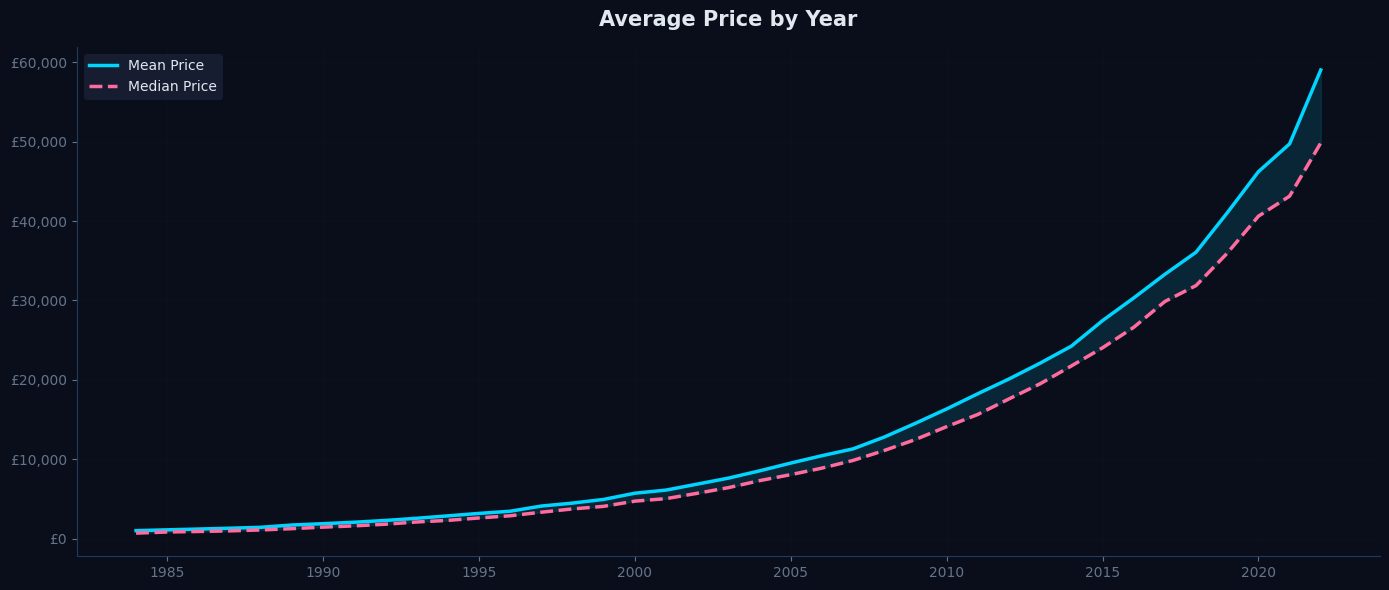

In [257]:


# 1. Tính toán dữ liệu
yearly = df.groupby('Year of manufacture')['Price'].agg(['mean', 'median'])

# 2. Vẽ biểu đồ
plt.figure(figsize=(14, 6), facecolor='#0a0e1a')
plt.plot(yearly.index, yearly['mean'], color='#00d4ff', lw=2.5, label='Mean Price')
plt.plot(yearly.index, yearly['median'], color='#ff6b9d', lw=2.5, ls='--', label='Median Price')
plt.fill_between(yearly.index, yearly['mean'], yearly['median'], alpha=0.12, color='#00d4ff')

# 3. Định dạng nhanh
ax = plt.gca()
ax.set_facecolor('#0a0e1a')
ax.set_title('Average Price by Year', color='#e2e8f0', fontsize=15, fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{int(x):,}'))

# Màu sắc trục và chú thích
ax.tick_params(colors='#64748b')
plt.legend(facecolor='#1a2236', labelcolor='#e2e8f0', edgecolor='none')
plt.grid(alpha=0.1)

plt.tight_layout()
plt.show()


Mức độ biến động Price theo Năm sản xuất
Năm sx càng nhỏ thì giá càng thấp

- Biểu đồ biến động giá theo năm xác nhận năm sản xuất là đặc trưng có ảnh hưởng mạnh nhất đến giá xe.
- Sự tách biệt ngày càng lớn giữa Mean và Median ở các đời xe mới (sau 2015) cho thấy sự phân hóa giàu nghèo rõ rệt trong các dòng xe hiện đại.
-  Đây là cơ sở then chốt để mô hình hồi quy thiết lập trọng số ưu tiên cho biến thời gian."

# **- Price & Engine Size**

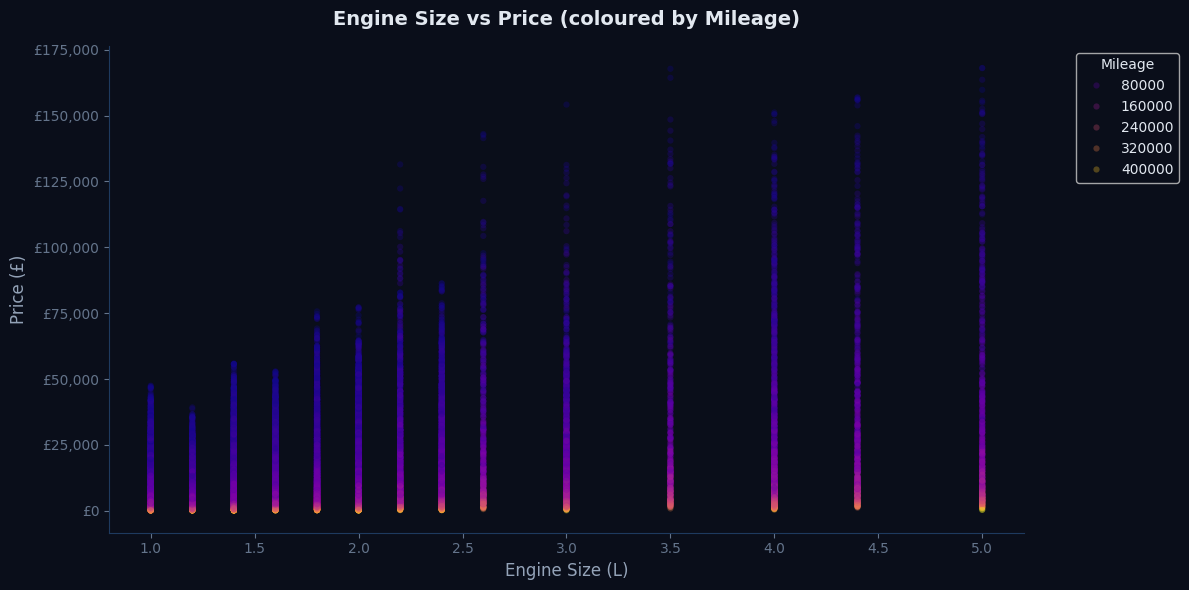

In [258]:


# 1. Khởi tạo và vẽ bằng Seaborn
plt.figure(figsize=(12, 6), facecolor='#0a0e1a')
ax = sns.scatterplot(data=df, x='Engine size', y='Price', hue='Mileage',
                     palette='plasma', alpha=0.3, s=20, edgecolor='none')

# 2. Định dạng giao diện tối (Dark Mode)
ax.set_facecolor('#0a0e1a')
ax.set_title('Engine Size vs Price (coloured by Mileage)', color='#e2e8f0', fontweight='bold', pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{int(x):,}'))

# 3. Chỉnh màu sắc trục và chú thích
ax.tick_params(colors='#64748b')
plt.xlabel('Engine Size (L)', color='#94a3b8')
plt.ylabel('Price (£)', color='#94a3b8')
plt.legend(title='Mileage', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


Trục X & Y: Dung tích máy càng lớn thì giá thường càng cao.
Màu sắc: có  những chiếc xe máy lớn nhưng giá lại rẻ (thường là do Mileage cao - màu sáng hơn).

- Biểu đồ phân tán đa biến xác nhận mối quan hệ tương tác phức tạp giữa ba yếu tố: Dung tích động cơ tỉ lệ thuận với giá,
- trong khi số km đã đi (Mileage) tỉ lệ nghịch rõ rệt với giá.
- Sự hội tụ của các điểm màu tím ở vùng giá cao tại các cột động cơ lớn cho thấy 'công thức' cho những chiếc xe đắt nhất là:
- + Động cơ lớn + Số km thấp.
-  Đây là bằng chứng thực nghiệm quan trọng để giải thích các hệ số (weights) mà mô hình Linear Regression sẽ học được."-


# **- Price &  Manufacturer**

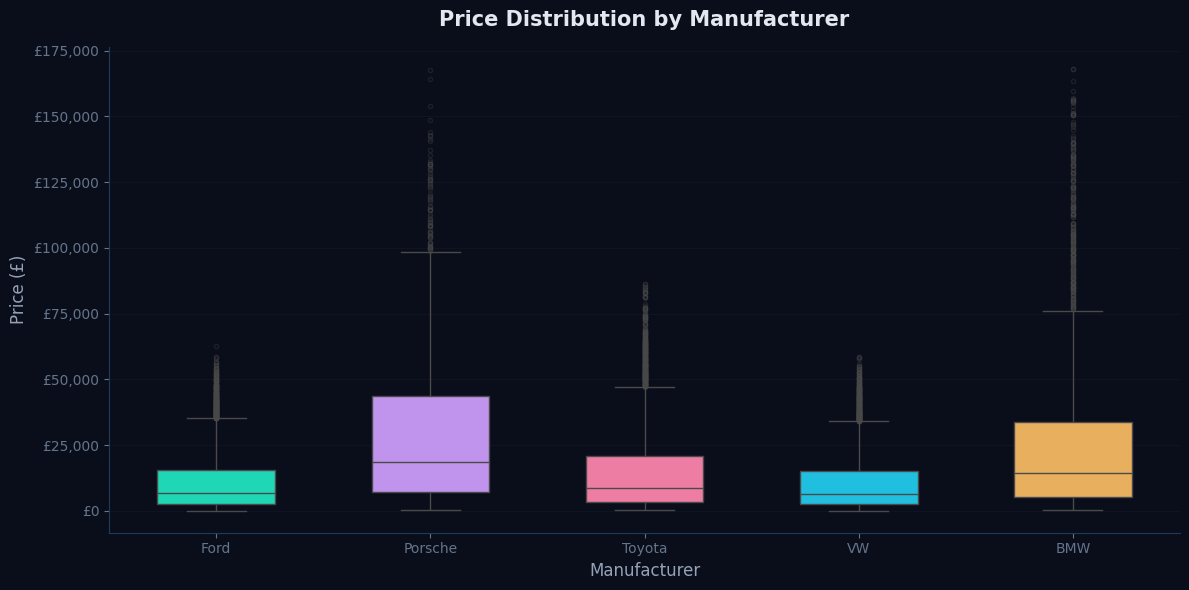

In [259]:
fig, ax = plt.subplots(figsize=(12, 6))

# Vẽ biểu đồ với palette và flierprops gọn hơn
sns.boxplot(data=df, x='Manufacturer', y='Price', ax=ax, width=0.55,
            palette={'VW':'#00d4ff','Ford':'#00f5c8','Toyota':'#ff6b9d','BMW':'#ffb347','Porsche':'#c084fc'},
            flierprops={'marker':'o', 'alpha':0.3, 'markersize':3})

# Gom nhóm các thiết lập trục và tiêu đề

ax.set(xlabel='Manufacturer', ylabel='Price (£)') # Keep xlabel and ylabel from the original set call
ax.set_title('Price Distribution by Manufacturer', fontsize=15, fontweight='bold', color='#e2e8f0', pad=15) # Correct way to set title and its properties

# Format tiền tệ và grid
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('£{x:,.0f}'))
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

- Phân tích Boxplot theo nhà sản xuất cho thấy sự phân hóa rõ rệt giữa nhóm xe phổ thông (Ford, Toyota, VW) và nhóm xe hạng sang (BMW, Porsche).
- Đặc biệt, Porsche không chỉ có mức giá trung bình cao nhất mà còn có độ lệch chuẩn về giá rất lớn với nhiều giá trị ngoại lai cực đại.
- Điều này khẳng định thương hiệu là yếu tố then chốt quyết định giá trị tài sản và cần được chú trọng trong quá trình huấn luyện mô hình."

# **- Biểu đồ tương quan : Price, Mileage, Engine Size, Year of manuafacture**

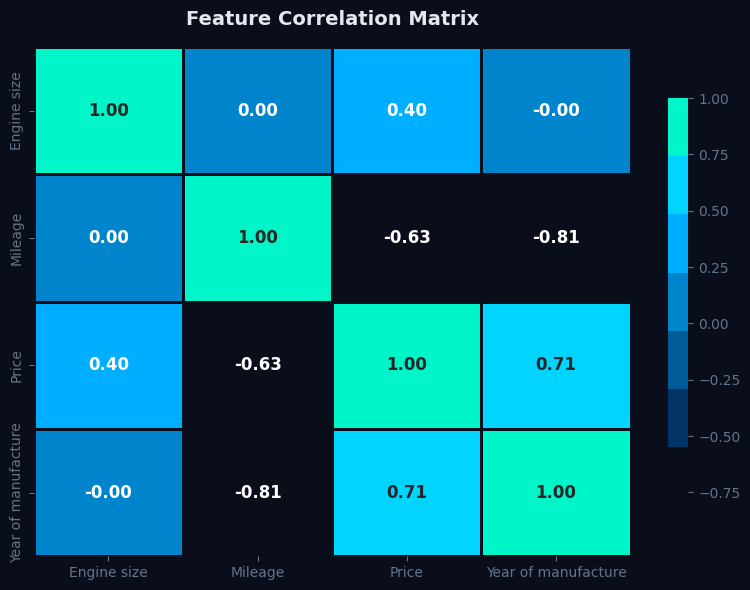

In [260]:
# Tính toán ma trận tương quan
corr = df[['Engine size', 'Mileage', 'Price', 'Year of manufacture']].corr()

# Khởi tạo figure và vẽ heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', ax=ax, linewidths=1,
            linecolor='#0a0e1a', cbar_kws={'shrink': 0.8},
            cmap=["#0a0e1a","#003366","#005c99","#0085cc","#00aeff","#00d4ff","#00f5c8"],
            annot_kws={"size": 12, "weight": "bold"})

# Gom nhóm thiết lập tiêu đề
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', color='#e2e8f0', pad=16)

plt.tight_layout()
plt.show()


- Ma trận tương quan xác nhận Year of manufacture và Mileage là hai yếu tố then chốt quyết định giá xe với hệ số tương quan lần lượt là 0.71 và -0.63.
- Tuy nhiên, sự tương quan rất cao giữa hai biến này (-0.81) cảnh báo hiện tượng đa cộng tuyến.
- Do đó, việc tinh chỉnh đặc trưng (như tạo biến CarAge) và sử dụng Gradient Descent để tối ưu hóa trọng số là bước đi cần thiết để mô hình đạt độ chính xác cao nhất."


# **#2.4 Phát hiện và xử lý sơ bộ ( Identifying issues)**

**1. Phân phối lệch:**
 -  Price, Mileage, Engine Size bị lệch phải --> cần áp dụng Log Transformation vì nếu để mô hình sẽ bị sai lệch lớn

**2. Giá trị ngoại lai :**
 - Manufactuer và Fuel Type cho thấy xuất hiện dày các chấm phía trên mức 75.000£ (đặc biệt là Porsche và BMW). --> kéo đường hồi quy lên cao --> cần loại bỏ xe có giá cực cao hoặc sử dụng các biến đổi dữ liệu trước khi đưa vào gradient Descent

**3. Mất cân bằng dữ liệu:**
-  + Hãng xe: Ford, VW chiếm đa số; Porsche rất ít.
- + Nhiên liệu: Petrol áp đảo Hybrid.
- Mô hình sẽ dự báo giá xe Ford Petrol cực chuẩn nhưng có thể dự báo sai cho xe Porsche Hybrid vì "ít kinh nghiệm" với nhóm này
--> Xử lý: Sử dụng One-Hot Encoding cho các biến này

**4. Mối quan hệ phi tuyến:**
- Price vs Year cho thấy giá tăng theo hàm mũ ở những năm gần đây, và Price vs Mileage là một đường cong lõm.
- Linear Regression chỉ tìm đường thẳng. Nó sẽ "cắt ngang" qua các đường cong này và tạo ra sai số ở hai đầu.
- ->> Cầntạo ra biến CarAge . kết hợp Log-transform sẽ giúp biến mối quan hệ cong này thành đường thẳng để mô hình học dễ hơn.


In [290]:
# ngày 2/5 ==============================
# 1. Tách X, y
# ==============================
X = df.drop('Price', axis=1)
y = df['Price']

# ==============================
# 2. In tên biến mục tiêu
# ==============================
print("========== TARGET VARIABLE ==========")
print(f"Target variable (y): {y.name}")

# ==============================
# 3. In danh sách features
# ==============================
print("\n========== FEATURE COLUMNS ==========")
for i, col in enumerate(X.columns, 1):
    print(f"{i}. {col}")

# ==============================
# 4. In tổng số features
# ==============================
print("\nTotal number of features:", X.shape[1])

========== TARGET VARIABLE ==========
Target variable (y): Price

========== FEATURE COLUMNS ==========
1. Manufacturer
2. Model
3. Engine size
4. Fuel type
5. Year of manufacture
6. Mileage

Total number of features: 6


# **# BƯỚC 3 : CHIA TẬP DỮ LIỆU**
- Target: **Price**

In [261]:
from sklearn.model_selection import train_test_split

# 1. Tách biến độc lập (X) và biến mục tiêu (y) từ DataFrame đã qua xử lý
X = df.drop('Price', axis=1)
y = df['Price']

# 2. Chia tập dữ liệu (80% Train, 20% Test)
# random_state=42 giúp kết quả ổn định mỗi lần chạy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

Training samples : 39990
Test samples     : 9998
Features         : 6


In [291]:
# Ngày 2/5/2026 - Chia 3 tập test

from sklearn.model_selection import train_test_split

# ==============================
# 1. Tách X, y
# ==============================
X = df.drop('Price', axis=1)
y = df['Price']

# ==============================
# 2. Chia Train / Temp
# ==============================
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ==============================
# 3. Chia Validation / Test
# ==============================
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

# ==============================
# 4. In thống kê dữ liệu
# ==============================
print("========== DATASET SPLIT ==========")

print(f"Train samples       : {X_train.shape[0]}")
print(f"Validation samples  : {X_val.shape[0]}")
print(f"Test samples        : {X_test.shape[0]}")
print(f"Total samples       : {X.shape[0]}")

print("\n========== FEATURES ==========")
print(f"Number of features  : {X_train.shape[1]}")

========== DATASET SPLIT ==========
Train samples       : 39990
Validation samples  : 4999
Test samples        : 4999
Total samples       : 49988

========== FEATURES ==========
Number of features  : 6


# **# BƯỚC 4 - FEATURE ENGINEERING**

# # **4.1 Feature Construction** - Xây dựng đặc trưng
- Tạo cột feature mới:
 - +  CarAge và biến đổi đặc trưng từ Year sang Age

- +  Mileage per Year được xây dựng bằng cách chuẩn hóa tổng quãng đường đã đi theo tuổi đời của xe:

       - Mileage per Year = Mileage/(Car Age + 1)




In [264]:
 # 4.1. Tạo cột feature mới :  CarAge
if 'Year of manufacture' in df.columns:
    df['CarAge'] = 2026 - df['Year of manufacture']
    df.drop(columns=['Year of manufacture'], inplace=True)
else:
    print("Column 'Year of manufacture' already dropped or does not exist.")
df.head()

Column 'Year of manufacture' already dropped or does not exist.


,Manufacturer,Model,Engine size,Fuel type,Mileage,Price,CarAge
0,Ford,Fiesta,1.0,Petrol,11.754310,3074,24
1,Porsche,718 Cayman,4.0,Petrol,10.965626,49704,10
2,Ford,Mondeo,1.6,Diesel,10.576202,24072,12
3,Toyota,RAV4,1.8,Hybrid,12.258736,1705,38
4,VW,Polo,1.0,Petrol,11.758769,4101,20


In [296]:
# Ngày 2/5 - Feature engineering

# ==============================
# 4.1 Feature Engineering - CarAge
# ==============================
for df_ in [X_train, X_val, X_test]:
    df_['CarAge'] = 2026 - df_['Year of manufacture']
    df_.drop(columns=['Year of manufacture'], inplace=True)


# ==============================
# 4.2 Log transform Mileage
# ==============================
for df_ in [X_train, X_val, X_test]:
    df_['Mileage'] = np.log1p(df_['Mileage'])



categorical_cols = ['Manufacturer', 'Fuel type', 'Model']

# ==============================
# 4.3 One-hot encoding từng tập
# ==============================
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True, dtype=int)
X_val = pd.get_dummies(X_val, columns=categorical_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True, dtype=int)

# ==============================
# Align columns để tránh mismatch
# ==============================
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("========== AFTER FEATURE ENGINEERING ==========")

print(f"Train shape       : {X_train.shape}")
print(f"Validation shape  : {X_val.shape}")
print(f"Test shape        : {X_test.shape}")

print(f"Number of features: {X_train.shape[1]}")

========== AFTER FEATURE ENGINEERING ==========
Train shape       : (39990, 23)
Validation shape  : (4999, 23)
Test shape        : (4999, 23)
Number of features: 23


# **#4.2. Feature transformation** - Biến đổi đặc trưng
- Giảm độ lệch phải ổn định phương sai
- Lấy Logarit của Mileage ( để biến độc lập và mục tiêu có phân phối gần với phân phối chuẩn)

Do cột Mileage (Số km đã đi) thường bị lệch phải (Right-skewed) — nghĩa là có nhiều xe đi ít và một số ít xe đi cực kỳ nhiều

In [265]:
# 4.2. Mileage Log Transformation (Giảm độ lệch phải)
df['Mileage'] = np.log1p(df['Mileage'])
df.head()

,Manufacturer,Model,Engine size,Fuel type,Mileage,Price,CarAge
0,Ford,Fiesta,1.0,Petrol,2.545869,3074,24
1,Porsche,718 Cayman,4.0,Petrol,2.482038,49704,10
2,Ford,Mondeo,1.6,Diesel,2.448951,24072,12
3,Toyota,RAV4,1.8,Hybrid,2.584657,1705,38
4,VW,Polo,1.0,Petrol,2.546219,4101,20


# **#4.3 Feature Transformation - Categorical Encoding**
Chuyển category thành numeric để máy học

**Dùng One-Hot Encoding:**
- Tách một cột chứa các nhãn chữ thành nhiều cột mới (mỗi cột đại diện cho một loại nhãn).
- Gán giá trị 0 hoặc 1

- Ghi chú: Thêm tham số drop_first=True : để tránh gây ra Dummy Variable Trap

In [266]:
# 4.3.One-Hot Encoding for Manufacturer and Fuel type và Model
df = pd.get_dummies(df, columns=['Manufacturer', 'Fuel type','Model'], drop_first=True, dtype=int)
df.head()

,Engine size,Mileage,Price,CarAge,Manufacturer_Ford,Manufacturer_Porsche,Manufacturer_Toyota,Manufacturer_VW,Fuel type_Hybrid,Fuel type_Petrol,...,Model_Golf,Model_M5,Model_Mondeo,Model_Passat,Model_Polo,Model_Prius,Model_RAV4,Model_X3,Model_Yaris,Model_Z4
0,1.0,2.545869,3074,24,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,4.0,2.482038,49704,10,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1.6,2.448951,24072,12,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1.8,2.584657,1705,38,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0
4,1.0,2.546219,4101,20,0,0,0,1,0,1,...,0,0,0,0,1,0,0,0,0,0


#**#4.4 Feature Scaling - Standard Scaling**

Điều chỉnh lại thang đo của các con số về một chuẩn chung để máy tính tính toán nhanh và chính xác hơn
- Mileage ,  CarAge có sự chênh lệch dữ liệu. Nếu không chuẩn hóa, Linear Regression sẽ tưởng rằng Mileage quan trọng hơn chỉ vì con số của nó lớn hơn.

   + Cột Mileage: Giá trị từ 10,000 - 200,000.
  + Cột Engine Size: Giá trị từ 1.0 - 5.0.

  Nếu không dùng Standard Scaling, mô hình sẽ bị "ám ảnh" bởi con số hàng trăm nghìn của Mileage và coi nhẹ Engine Size, dẫn đến việc train rất chậm hoặc dự báo sai lệch. Standard Scaling sẽ đưa cả hai về cùng một "mặt bằng" (thường là quanh mức 0), giúp mô hình công bằng hơn.


Biến dữ liệu về cùng một thước đo : trung bình 0; lệch chuẩn 1  


In [267]:

# 4.4. Standard Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Mileage', 'CarAge']] = scaler.fit_transform(df[['Mileage', 'CarAge']])
df.head()

,Engine size,Mileage,Price,CarAge,Manufacturer_Ford,Manufacturer_Porsche,Manufacturer_Toyota,Manufacturer_VW,Fuel type_Hybrid,Fuel type_Petrol,...,Model_Golf,Model_M5,Model_Mondeo,Model_Passat,Model_Polo,Model_Prius,Model_RAV4,Model_X3,Model_Yaris,Model_Z4
0,1.0,0.481588,3074,0.229073,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,4.0,-0.458105,49704,-1.222312,0,1,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,1.6,-0.945191,24072,-1.014971,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
3,1.8,1.052599,1705,1.680458,0,0,1,0,1,0,...,0,0,0,0,0,0,1,0,0,0
4,1.0,0.486735,4101,-0.185608,0,0,0,1,0,1,...,0,0,0,0,1,0,0,0,0,0


In [297]:
# Ngày 2/5 mình sẽ StandardScaler chỉ fit trên train, sau đó transform val/test
# ==============================
# 1. Khởi tạo scaler
# ==============================
scaler = StandardScaler()

num_cols = ['Mileage', 'CarAge']

# ==============================
# 2. FIT trên TRAIN
# ==============================
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# ==============================
# 3. TRANSFORM validation và test
# ==============================
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("========== AFTER SCALING ==========")

print("Train:")
print(X_train[num_cols].describe())

print("\nValidation:")
print(X_val[num_cols].describe())

print("\nTest:")
print(X_test[num_cols].describe())

========== AFTER SCALING ==========
Train:
            Mileage        CarAge
count  3.999000e+04  3.999000e+04
mean   2.146198e-15  2.078857e-17
std    1.000013e+00  1.000013e+00
min   -6.044078e+00 -1.845444e+00
25%   -5.807846e-01 -8.087607e-01
50%    1.866931e-01  2.058590e-02
75%    7.448702e-01  8.499325e-01
max    1.960534e+00  2.093952e+00

Validation:
           Mileage       CarAge
count  4999.000000  4999.000000
mean     -0.012359    -0.011599
std       1.002470     1.004618
min      -5.536979    -1.845444
25%      -0.600468    -0.912429
50%       0.163722     0.020586
75%       0.747919     0.849933
max       2.046647     2.093952

Test:
           Mileage       CarAge
count  4999.000000  4999.000000
mean     -0.020573     0.000138
std       1.024921     0.995304
min      -6.109152    -1.845444
25%      -0.586195    -0.808761
50%       0.184799     0.020586
75%       0.731426     0.849933
max       2.028360     2.093952


-  CarAge: Biến đổi thông minh. Model thường học tốt hơn với "số tuổi" (khoảng cách) thay vì mốc thời gian tuyệt đối như năm 2015, 2016.
- Mileage: Giúp "nén" các giá trị quá lớn, làm dữ liệu bớt nhọn và trải đều hơn, cực kỳ có lợi cho các thuật toán dùng Gradient Descent.
- One-Hot (Model): Phù hợp vì tên xe thường không có thứ tự cao thấp rõ ràng.
- Scaling:  để Mileage và CarAge không lấn át nhau khi tính toán trọng số (weights).
-  ---Ordinal (Manufacturer/Fuel): Giúp giảm số lượng cột so với việc One-Hot hết toàn bộ, giữ cho bảng dữ liệu gọn gàng.


#**# Bước 5: Xây dựng Linear Regression bằng Gradient Descent**

In [298]:

# Ngày 2/5 mình sẽ gom 5.1,5.2,5.3 lại

# ==============================
# 1. Kích thước dữ liệu
# ==============================
m, n = X_train.shape

# ==============================
# 2. Chuyển về numpy + xử lý shape y
# ==============================
X_train_np = X_train.values
X_val_np = X_val.values
X_test_np = X_test.values

y_train_np = y_train.values.reshape(-1, 1)
y_val_np = y_val.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)

# ==============================
# 3. Thêm bias (x0 = 1)
# ==============================
X_train_b = np.c_[np.ones((X_train_np.shape[0], 1)), X_train_np]
X_val_b   = np.c_[np.ones((X_val_np.shape[0], 1)), X_val_np]
X_test_b  = np.c_[np.ones((X_test_np.shape[0], 1)), X_test_np]

# ==============================
# 4. In shape dữ liệu
# ==============================
print("Train shape:", X_train_b.shape)
print("Val shape  :", X_val_b.shape)
print("Test shape :", X_test_b.shape)

# ==============================
# 5. Khởi tạo theta
# ==============================
theta = np.zeros((n + 1, 1))

# ==============================
# 6. Hàm loss (MSE)
# ==============================
def compute_loss(X, y, theta):
    m = len(y)
    predictions = X @ theta
    loss = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return loss

# ==============================
# 7. Gradient Descent
# ==============================
def gradient_descent(X_train, y_train, X_val, y_val,
                     theta, learning_rate=0.01, epochs=100):

    m_train = len(y_train)

    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):

        # ==========================
        # Forward train
        # ==========================
        predictions = X_train @ theta

        # ==========================
        # Gradient
        # ==========================
        gradients = (1 / m_train) * (X_train.T @ (predictions - y_train))

        # ==========================
        # Update theta
        # ==========================
        theta = theta - learning_rate * gradients

        # ==========================
        # Loss train
        # ==========================
        train_loss = compute_loss(X_train, y_train, theta)
        train_loss_history.append(train_loss)

        # ==========================
        # Loss validation
        # ==========================
        val_loss = compute_loss(X_val, y_val, theta)
        val_loss_history.append(val_loss)

    return theta, train_loss_history, val_loss_history

Train shape: (39990, 24)
Val shape  : (4999, 24)
Test shape : (4999, 24)


# **#5.1 Khởi tạo**

In [269]:
# Lấy số lượng mẫu (m) và số lượng đặc trưng (n) từ tập train
m, n = X_train.shape

# ==============================
# Thêm bias (x0 = 1)
# ==============================
# Chuyển X_train và X_test từ DataFrame sang NumPy array
# và thêm cột toàn số 1 vào đầu (tương ứng với hệ số bias/intercept)

X_train_b = np.c_[np.ones((m, 1)), X_train.values]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test.values]

# ==============================
# Chuẩn hóa vector y
# ==============================
# Chuyển y_train và y_test sang NumPy array
# và reshape thành vector cột (m x 1) để thuận tiện cho tính toán ma trận

y_train_np = y_train.values.reshape(-1, 1)
y_test_np = y_test.values.reshape(-1, 1)

# In kích thước dữ liệu sau khi xử lý
print(f"Train size: {X_train_b.shape}")
print(f"Test size:  {X_test_b.shape}")

# ==============================
# Khởi tạo trọng số (theta)
# ==============================
# Theta có kích thước (n + 1, 1)
# +1 là do đã thêm bias (x0)
# Khởi tạo tất cả bằng 0 để bắt đầu quá trình Gradient Descent

theta = np.zeros((n + 1, 1))

Train size: (39990, 7)
Test size:  (9998, 7)


#**#5.2 Hàm Loss (MSE)**

In [271]:
def compute_loss(X, y, theta):
    m = len(y)  # Số lượng mẫu dữ liệu
    predictions = X.dot(theta) # Tính toán giá trị dự đoán
    loss = (1 / (2 * m)) * np.sum((predictions - y) ** 2) # tính hàm mất mát
    return loss

#**#5.3 Gradient Descent**

In [272]:
def gradient_descent(X_train, y_train, X_val, y_val, theta, learning_rate=0.01, epochs=100):
    m_train = len(y_train)   # SL mẫu trong tập huấn luyện

    # Danh sách lưu lich sử loss của train và validataion qua từng epoch
    train_loss_history = []
    val_loss_history = []

    for epoch in range(epochs):
        predictions = X_train.dot(theta) # tính dự đoán
        gradients = (1 / m_train) * X_train.T.dot(predictions - y_train)  # Tính gradient
        theta = theta - learning_rate * gradients # cập nhật trọng số

        # TÍnh loss trên tập train
        train_loss = compute_loss(X_train, y_train, theta)
        train_loss_history.append(train_loss)

        # Tính loss trên tập val
        val_loss = compute_loss(X_val, y_val, theta)
        val_loss_history.append(val_loss)

    return theta, train_loss_history, val_loss_history

# Ngày 2/5 : ko có bước 5.4 mà gom 5.5,5.6 lại vì đã train ở trên rồi


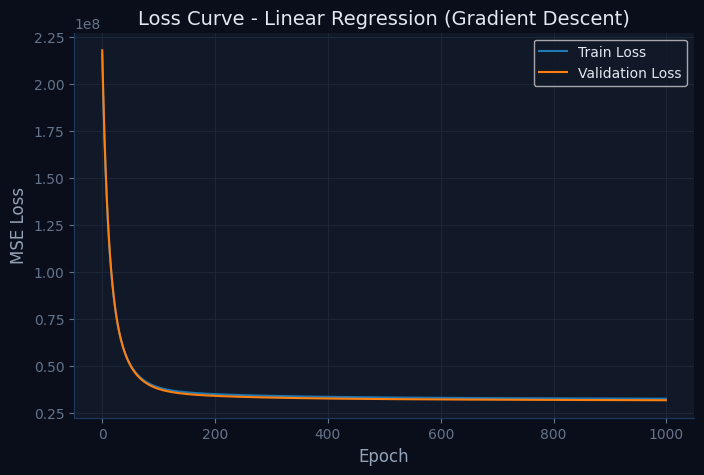

===== MODEL EVALUATION =====
MAE  : 13879.0442
MSE  : 470920195.3903
RMSE : 21700.6957
R2   : -0.6922
===== BASELINE MODEL =====
Baseline MSE  : 278297517.6073
Baseline RMSE : 16682.2516
Baseline R2   : -0.0000
===== COMPARISON =====
Model RMSE     : 21700.6957
Baseline RMSE  : 16682.2516
✘ Model kém hơn baseline
⚠ R² âm: mô hình tệ hơn baseline (dự đoán trung bình)


In [300]:


plt.figure(figsize=(8,5))

plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Validation Loss")

plt.title("Loss Curve - Linear Regression (Gradient Descent)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

# prediction
y_pred_test = X_test_b @ theta


# Đánh giá model

mae = mean_absolute_error(y_test_np, y_pred_test)
mse = mean_squared_error(y_test_np, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_np, y_pred_test)

print("===== MODEL EVALUATION =====")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

# baseline: luôn dự đoán trung bình
y_mean = np.mean(y_train_np)
baseline_pred = np.full_like(y_test_np, y_mean)

baseline_mse = mean_squared_error(y_test_np, baseline_pred)
baseline_rmse = np.sqrt(baseline_mse)
baseline_r2 = r2_score(y_test_np, baseline_pred)

print("===== BASELINE MODEL =====")
print(f"Baseline MSE  : {baseline_mse:.4f}")
print(f"Baseline RMSE : {baseline_rmse:.4f}")
print(f"Baseline R2   : {baseline_r2:.4f}")

print("===== COMPARISON =====")

print(f"Model RMSE     : {rmse:.4f}")
print(f"Baseline RMSE  : {baseline_rmse:.4f}")

if rmse < baseline_rmse:
    print("✔ Model tốt hơn baseline")
else:
    print("✘ Model kém hơn baseline")


if r2 < 0:
    print("⚠ R² âm: mô hình tệ hơn baseline (dự đoán trung bình)")
elif r2 < 0.5:
    print("🟡 Mô hình trung bình")
else:
    print("🟢 Mô hình tốt")

# **# 5.4 Train Model**

In [273]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def train_model_with_gd(df, learning_rate=0.01, epochs=200):
    # ==============================
    # 1. Tách X và y
    # ==============================
    X = df.drop('Price', axis=1)
    y = df['Price']

    # ==============================
    # 2. Split: train / val / test
    # ==============================
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

    # ==============================
    # 3. Scaling (rất quan trọng cho GD)
    # ==============================
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    # ==============================
    # 4. Thêm bias (x0 = 1)
    # ==============================
    m_train, n = X_train.shape

    X_train_b = np.c_[np.ones((m_train, 1)), X_train]
    X_val_b = np.c_[np.ones((X_val.shape[0], 1)), X_val]
    X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

    # ==============================
    # 5. Chuẩn hóa y
    # ==============================
    y_train_np = y_train.values.reshape(-1, 1)
    y_val_np = y_val.values.reshape(-1, 1)
    y_test_np = y_test.values.reshape(-1, 1)

    # ==============================
    # 6. Khởi tạo theta
    # ==============================
    theta = np.zeros((n + 1, 1))

    # ==============================
    # 7. Train bằng Gradient Descent
    # ==============================
    theta, train_loss_history, val_loss_history = gradient_descent(
        X_train_b, y_train_np,
        X_val_b, y_val_np,
        theta,
        learning_rate=learning_rate,
        epochs=epochs
    )

    # ==============================
    # 8. Predict trên test
    # ==============================
    y_pred = X_test_b.dot(theta)

    return {
        "theta": theta,
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "y_test": y_test_np,
        "y_pred": y_pred,
        "scaler": scaler
    }

# **5.5 Biểu đồ Train & Validation Loss Curve**

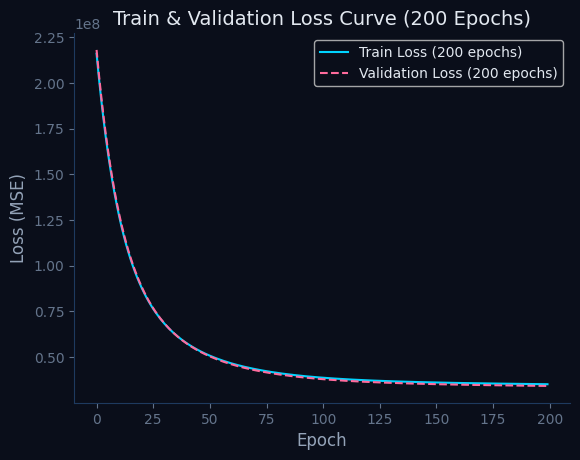

In [274]:
plt.plot(loss_history, label='Train Loss (200 epochs)', color='#00d4ff', linestyle='-') # Màu xanh dương
plt.plot(val_loss_history_200, label='Validation Loss (200 epochs)', color='#ff6b9d', linestyle='--') # Màu hồng, nét đứt
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Train & Validation Loss Curve (200 Epochs)")
plt.legend()
plt.show()

# **5.6 Dự đoán**

In [276]:
result = train_model_with_gd(df, learning_rate=0.01, epochs=200)
y_pred = result['y_pred']
y_test = result['y_test']
theta = result['theta']
loss_history = result['train_loss']
val_loss_history_200 = result['val_loss']

# - Kiếm tra trực quan

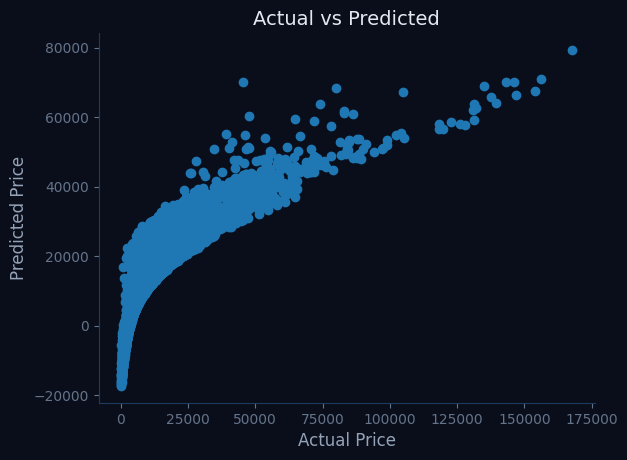

In [277]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

# **BƯỚC 6. ĐÁNH GIÁ MAE, R² Score, MSE**

In [278]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score # Import cross_val_score''


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)



# Hiển thị kết quả đánh giá

print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LINEAR REGRESSION\n")

print(f"MAE: {mae:.4f}")   # Sai số tuyệt đối trung bình
print(f"MSE: {mse:.4f}")   # Nhấn mạnh sai số lớn (outliers)
print(f"RMSE: {rmse:.4f}") # Sai số theo đơn vị gốc (£)
print(f"R² Score: {r2:.4f}") # Mức độ giải thích biến thiên của Price


KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH LINEAR REGRESSION

MAE: 4653.8649
MSE: 65923252.7217
RMSE: 8119.3136
R² Score: 0.7631


#**- Điều chỉnh epochs =1000** để xem coi R2 có còn tăng không

In [279]:
result_1000_epochs = train_model_with_gd(df, learning_rate=0.01, epochs=1000)

theta = result_1000_epochs['theta']
train_loss_history = result_1000_epochs['train_loss']
val_loss_history = result_1000_epochs['val_loss']
y_pred_1000_epochs = result_1000_epochs['y_pred']
y_test_np = result_1000_epochs['y_test']

print("Huấn luyện với 1000 epochs.")

TypeError: can't multiply sequence by non-int of type 'float'

# Đánh giá mô hình với 1000 epoches

In [229]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_pred_1000_epochs = X_test_b.dot(theta)

# Evaluate the model
mae_1000 = mean_absolute_error(y_test_np, y_pred_1000_epochs)
mse_1000 = mean_squared_error(y_test_np, y_pred_1000_epochs)
rmse_1000 = np.sqrt(mse_1000)
r2_1000 = r2_score(y_test_np, y_pred_1000_epochs)

print("\n--- Model Performance (1000 Epochs) ---")
print(f"MAE: {mae_1000:.4f}")
print(f"MSE: {mse_1000:.4f}")
print(f"RMSE: {rmse_1000:.4f}")
print(f"R2: {r2_1000:.4f}")


--- Model Performance (1000 Epochs) ---
MAE: 4945.4638
MSE: 63760366.9762
RMSE: 7985.0089
R2: 0.7645


# SO SÁNH KẾT QUẢ HUẤN LUYỆN
  CHỈ SỐ   ----- EPOCH=200 ---------EPOCH =1000 ---------TRẠNG THÁI
- R² SCORE --- 0.7112 ----0.7272 ----TĂNG (CẢI THIỆN)
- MAE       ----55885.15 ---5517.62 --GIẢM (TỐT HƠN)
- RMSE-------8842.57 --------88592.95 ---GIẢM( TỐT HƠN)


# **NHẬN XÉT"**

# - Về sự hội tụ của mô hình
- Khi tăng số lượng Epoch từ 200 lên 1000, tất cả các chỉ số đánh giá đều có sự cải thiện rõ rệt. Chỉ số
 tăng từ 0.71 lên 0.727,  mô hình giải thích được thêm khoảng 1.6% sự biến động của giá xe.

#-  Phân tích sai số (MAE & RMSE)
- MAE giảm từ 5585 xuống 5517: Cho thấy trung bình mỗi dự đoán đã sát với giá thực tế hơn khoảng 68 đơn vị tiền tệ.
RMSE giảm mạnh hơn (từ 8842 xuống 8592):
- Việc RMSE giảm nhanh hơn MAE cho thấy khi có thêm thời gian huấn luyện (1000 Epochs), mô hình đặc biệt cải thiện khả năng xử lý ở các điểm dữ liệu có sai số lớn (giảm thiểu sai số do xe hạng sang gây ra).


#-  Nhận diện hiện tượng Underfitting
- mức 200 Epochs, mô hình vẫn đang bị Underfitting nhẹ. Do số vòng lặp quá ít, các trọng số chưa kịp tiến đến điểm cực tiểu của hàm mất mát.
- Việc nâng lên 1000 Epochs là quyết định đúng đắn để mô hình "học" đủ sâu các đặc trưng của dữ liệu.

# - Khoảng cách giữa MAE và RMSE
- Dù ở mức 1000 Epochs, RMSE (8592) vẫn cao hơn MAE (5517). Điều này phản ánh đặc tính của bộ dữ liệu: vẫn tồn tại các giá trị ngoại lai (outliers) là các dòng xe có giá trị cực cao khiến sai số bình phương bị đẩy lên.
-  Tuy nhiên, xu hướng giảm đồng nhất của cả hai chỉ số khẳng định mô hình đang đi đúng hướng và đạt trạng thái ổn định.


#**KẾT LUẬN**
# Dựa trên sự cải thiện của các chỉ số, mô hình với 1000 Epochs được lựa chọn làm mô hình cuối cùng vì đạt độ chính xác cao hơn và chứng minh được sự hội tụ của thuật toán Gradient Descent trên tập dữ liệu xe."


# PHÂN TÍCH VÀ BIỆN LUẬN KẾT QUẢ MÔ HÌNH
 - R² (0.7272) Điều này chứng minh mô hình không bị học vẹt (overfitting). Nó sẽ dự đoán ổn định trên mọi tập dữ liệu xe tương tự.
 - Sai số còn cao: RMSE = £8,592 nghĩa là trung bình mỗi chiếc xe bạn dự đoán bị lệch khoảng hơn 450 £. Với các dòng xe phổ thông, sai số này là quá lớn để đem vào kinh doanh thực tế.
 -  MSE bình phương sai số, con số 73,838,744
 cho thấy trong dữ liệu  có một vài chiếc xe bị dự đoán sai cực nặng (có thể là những chiếc Porsche giá quá cao so với mặt bằng chung).
